In [1]:
#| echo: false
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk

%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.family": "serif",      # Use serif fonts for text
    "mathtext.fontset": "cm",    # 'cm' stands for Computer Modern (Standard LaTeX font)
})

import warnings
warnings.filterwarnings('ignore', message='divide by zero encountered')

# Root Finding Methods

## Basic concepts

The equation $f(x)=0$, or a system of them, is the true atom of all mathematical models. The structure of $f$ comes in a variety of flavors and we are interested in a solution $x^*$ to the equation. For example in the linear case $\mathbf{A x}=\mathbf{b}$ for instance, a system with one million unknown is routinely solved when it comes to the well known finite element method for solving partial differential equations numerically. In the nonlinear case the idea is to use pure search methods or to linearize the system into a sequence of linear systems. In the one-dimensional case there sometimes exists simple solution formulas. A classical example that we are all familiar with is the case in which $f(x)$ is a quadratic polynomial, $f(x)=x^2+a x+b$. It is then well-known that the solution is given by a simple formula

$$
x_{1,2}^*=-\frac{a}{2} \pm \sqrt{\left(\frac{a}{2}\right)^2-b}
$$

In the case of polynomial equations the solutions are also known as roots. There are known formulas (Girolamo Cardano, 1501-1576, Italian mathematician) for finding roots of polynomials of degree 3 and 4, but these are rather complex. In more general cases, when $f(x)$ is a polynomial of degree greater than 4 , formulas for the roots no longer exist (Niels Henrik Abel, 1802-1829, Norwegian mathematician). Of course, there is no reason to limit ourselves to studying polynomials, and in most cases, when $f(x)$ is an arbitrary function, there are no analytic tools for calculating the desired solution. Instead, we must use approximation methods. In fact, even in cases in which exact formulas are available (such as with polynomials of degree 2,3 or 4 ) an exact formula might be too complex (require to much time to evaluate) to be used in practice. An approximate numerical method may, on the other hand, provide an accurate solution rather more quickly.

For many other equations, such as [transcendental equations](https://en.wikipedia.org/wiki/Transcendental_equation) (involving exponential, logarithmic or trigonometric functions), no exact solution formulas are known. In these cases, numerical methods are the only way to find approximate solutions. One of the most famous examples is Kepler's equation, which relates the position of a planet in its orbit to time. Kepler's equation is given by

$$
m = x - e \sin(x)
$$

where $m$ is the mean anomaly, $x$ is the eccentric anomaly, and $e$ is the eccentricity of the orbit. Rearranging this equation to the standard root-finding form gives
$$
f(x) = x - e \sin(x) - m = 0
$$

This equation cannot be solved analytically for $x$ in terms of elementary functions, so numerical methods are used to find approximate solutions for given values of $m$ and $e$.

The methods that we will describe all belong to the category of iterative methods. Such methods will typically start with an initial guess $x_0$ in the neighborhood of the solution and then generate a sequence $x_0, x_1, \ldots$ of hopefully even better approximations, and eventually terminating in $x^*$ to a desired tolerance. When applying iterative methods in practice, we must first determine how many solutions exist and which one is of interest for the application at hand—visualizing the function is invaluable here. We must also consider whether we seek real or complex solutions, as this affects method selection. The question of convergence is central: does the method approach the solution, and if so, how fast? Methods that fail to converge are said to diverge. We must decide on a desired tolerance for the solution, with a common termination criterion being $\left|x_{k+1}-x_k\right|<\varepsilon$ for some small $\varepsilon > 0$. Finally, the computational speed of the method may be critical in applications requiring real-time solutions or processing large problem sets.

There is a large number of different iterative methods, some of which are highly specialized to solve certain types of problems. The methods are mainly divided into derivative free or not. Methods that make use of the derivative of $f$ usually gain more information along the road and the convergence is therefore in general faster. On the other hand, if derivatives of $f$ may not be available, or are to expensive to evaluate, derivative free methods need to be used. In fact the derivative free methods are often the simplest, and most robust ones. We present some of the most widely used.

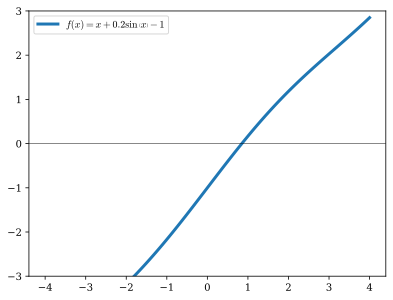

In [2]:
#| echo: false
#| classes: size-80
x = sp.symbols('x')
f = x -  1 + sp.sin(x)*0.2
# g = x
range = [-4,4]
mk.fplot(f, range=range, label=f'$f(x)={sp.latex(f)}$', lw=3)
plt.axhline(0, color='black', lw=0.5)
plt.gca().legend() 
plt.gca().set_ylim([-3,3])
plt.show()

## The Bisection Method

This is one of the most intuitive derivative free methods one can easily come up with, it is called the bisection method, and is applicable to a function of one variable. We have a function $f$ which we assume is continuous on the interval $[a, b]$. We also assume that it has opposite signs at both edges of the interval, i.e., $f(a) f(b)<0$. We then know, from the intermediate theorem, that $f(x)=0$ has at least one solution in $[a, b]$. Of course there may be more than one solution in the interval, but the bisection method is only going to converge to one of the them. If approaching the wrong one, simple narrow $[a, b]$, covering the solution desired, and start again. As usual, a nice plot of the scenario is never wrong!

The story goes like this. The first step is to calculate the midpoint $c=\frac{1}{2}(a+b)$ of the interval. This generates two subintervals, $[a, c]$ and $[c, b]$, of equal length. We want to keep the subinterval that is guaranteed to contain a solution. Of course, in the rare event where $f(c)=0$ we are done. Otherwise, we check if $f(a) f(c)<0$. If yes, we keep the left subinterval $[a, c]$, otherwise we keep the right subinterval $[c, b]$. This procedure repeats until the stopping criterion $|f(c)|<\delta$ or $b-a<\varepsilon$ is satisfied, due to some predefined small parameters $\delta, \varepsilon>0$. Then we choose $x^*=c$.

:::{#exm-bisection}
Find the largest root to  $x^2-x-6=0$ using the Bisection method. Compare with the exact one.

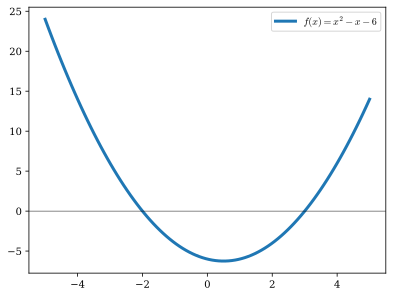

In [3]:
#| echo: false
#| classes: size-80
x = sp.symbols('x')
f = x**2 - x - 6
range = [-5, 5]
mk.fplot(f, range=range, label=f'$f(x)={sp.latex(f)}$', lw=3)
plt.axhline(0, color='black', lw=0.5)
plt.gca().legend() 
# plt.gca().set_ylim([-3,3])
plt.show()

The exact root using `sympy.solve()`

In [4]:
#| code-fold: false
sp.solve(f, x)

[-2, 3]

Go for $x^*=3$, using Bisection method. Let $\varepsilon=0.1$, and visually from the graph a starting interval $[1,4]$ ought to work. There is one solution only, so we expect a true success while iterating.

In [5]:
#| code-fold: false
a, b = (1, 4) # initial interval

i = 1 # iteration counter
while (b-a) > 0.01: # stopping criterion
    c = (a + b) / 2 # midpoint
    if f.subs(x, c) * f.subs(x, a) < 0: # root in [a,c]
        b = c # update b
    else:
        a = c # root in [c,b], update a
    i += 1 # increment iteration counter
    print(f"Iteration {i}: a = {a:0.3f}, b = {b:0.3f}, c = {c:0.3f}, f(c) = {f.subs(x, c):0.3f}")
    if i > 100: # safeguard against infinite loops
        print("Max iterations reached"); break

Iteration 2: a = 2.500, b = 4.000, c = 2.500, f(c) = -2.250
Iteration 3: a = 2.500, b = 3.250, c = 3.250, f(c) = 1.312
Iteration 4: a = 2.875, b = 3.250, c = 2.875, f(c) = -0.609
Iteration 5: a = 2.875, b = 3.062, c = 3.062, f(c) = 0.316
Iteration 6: a = 2.969, b = 3.062, c = 2.969, f(c) = -0.155
Iteration 7: a = 2.969, b = 3.016, c = 3.016, f(c) = 0.078
Iteration 8: a = 2.992, b = 3.016, c = 2.992, f(c) = -0.039
Iteration 9: a = 2.992, b = 3.004, c = 3.004, f(c) = 0.020
Iteration 10: a = 2.998, b = 3.004, c = 2.998, f(c) = -0.010


In [6]:
#| code-fold: true
from matplotlib.animation import FuncAnimation

# Recreate bisection iterations for animation
a_init, b_init = (1, 4)
tol = 0.01
a_vals = [a_init]
b_vals = [b_init]
c_vals = []
diffs = []

a_temp, b_temp = a_init, b_init
while (b_temp - a_temp) > tol:
    c_temp = (a_temp + b_temp) / 2
    diffs.append(b_temp - a_temp)
    c_vals.append(c_temp)
    if float(f.subs(x, c_temp) * f.subs(x, a_temp)) < 0:
        b_temp = c_temp
    else:
        a_temp = c_temp
    a_vals.append(a_temp)
    b_vals.append(b_temp)

# Generate function values for plotting
x_plot = np.linspace(-1, 5, 400)
f_numpy = sp.lambdify(x, f, 'numpy')
y_plot = f_numpy(x_plot)

# Create animation
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

def animate(frame):
    ax.clear()

    # Problem info box at top center
    problem_text = r"$f(x) = x^2 - x - 6$"
    ax.text(0.5, 0.98, problem_text,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    # Plot function
    ax.plot(x_plot, y_plot, 'b-', lw=2, label='$f(x)$')
    ax.axhline(0, color='black', lw=0.5, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

    if frame < len(c_vals):
        a_curr = a_vals[frame]
        b_curr = b_vals[frame]
        c_curr = c_vals[frame]

        f_a = float(f.subs(x, a_curr))
        f_b = float(f.subs(x, b_curr))
        f_c = float(f.subs(x, c_curr))

        # Highlight current interval
        ax.axvspan(a_curr, b_curr, alpha=0.2, color='yellow', label='Current Interval')

        # Mark interval endpoints
        ax.plot(a_curr, f_a, 'ro', markersize=8, label='$a$', zorder=5)
        ax.plot(b_curr, f_b, 'go', markersize=8, label='$b$', zorder=5)

        # Mark midpoint
        ax.plot(c_curr, f_c, 'ms', markersize=10, label='$c = \\frac{a+b}{2}$', zorder=5)

        # Vertical lines to x-axis
        ax.plot([a_curr, a_curr], [0, f_a], 'r--', lw=1, alpha=0.5)
        ax.plot([b_curr, b_curr], [0, f_b], 'g--', lw=1, alpha=0.5)
        ax.plot([c_curr, c_curr], [0, f_c], 'm--', lw=1, alpha=0.5)

        # Info text box in lower right
        interval_width = b_curr - a_curr

        # Determine which interval is kept
        if float(f.subs(x, c_curr) * f.subs(x, a_curr)) < 0:
            next_interval = f"$[{a_curr:.3f}, {c_curr:.3f}]$"
            reason = "$f(a) \\cdot f(c) < 0$"
        else:
            next_interval = f"$[{c_curr:.3f}, {b_curr:.3f}]$"
            reason = "$f(c) \\cdot f(b) < 0$"

        info_text = (
            f"Iteration {frame + 1}\n"
            f"$a = {a_curr:.4f}, \\quad f(a) = {f_a:.4f}$\n"
            f"$b = {b_curr:.4f}, \\quad f(b) = {f_b:.4f}$\n"
            f"$c = {c_curr:.4f}, \\quad f(c) = {f_c:.4f}$\n"
            f"Interval width: ${interval_width:.4f}$\n"
            f"{reason}\n"
            f"Next: {next_interval}"
        )

        ax.text(0.98, 0.02, info_text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    ax.set_title(f"Bisection Method: Iteration {frame + 1}, a-b = {diffs[frame-1]:.4f}" if frame > 0 else "Bisection Method: Initial Interval")
    ax.legend(loc='upper left', fontsize=8)
    ax.set_xlim(0, 4.5)
    ax.set_ylim(-8, 10)

anim = FuncAnimation(fig, animate, frames=len(c_vals), interval=1000, repeat=True)
plt.close()

mk.to_responsive_html(anim, container_id='bisection-animation')

:::

### Convergence of the Bisection Method

We would now like to understand if the bisection method always converges to a solution. We would also like to figure out how close we are to a solution after iterating the algorithm several times. Let $\left[a_k, b_k\right]$ be the interval after $k$ iterations, and note that

$$
a_0 \leq a_1 \leq a_2 \leq \ldots \leq b_0 \text {, and } b_0 \geq b_1 \geq b_2 \geq \ldots \geq a_0 \text {. }
$$


We also know that every iteration shrinks the length of the interval by half, i.e.

$$
b_k-a_k=\frac{1}{2}\left(b_{k-1}-a_{k-1}\right)
$$

which means that

$$
b_k-a_k=2^{-k}\left(b_0-a_0\right) .
$$

The sequences $\left\{a_k\right\}$ and $\left\{b_k\right\}$ are monotone and bounded, and hence converge. Also

$$
\lim _{k \rightarrow \infty}\left(b_k-a_k\right)=\lim _{k \rightarrow \infty}\left(2^{-k}\left(b_0-a_0\right)\right)=0,
$$

so that both sequences converge to the same value. We denote that value by $x^*$, i.e.

$$
\lim _{k \rightarrow \infty} a_k=\lim _{k \rightarrow \infty} b_k=x^*
$$


Since $f\left(a_k\right) f\left(b_k\right) \leq 0$, we know that $f\left(x^*\right)^2 \leq 0$, which means that $f\left(x^*\right)=0$, i.e., $x^*$ is a solution.

See the video explanation: [Bisection Method Video](https://www.youtube.com/watch?v=qBAMl94gMjc)

## Fixed point Iteration

[Fixed Point Method Video](https://youtu.be/qBAMl94gMjc?t=153)

### Keplers problem

{{< video https://youtu.be/hBkmyJ3TE0g >}}

## Newton's Method

[Newton's method video](https://youtu.be/qBAMl94gMjc?t=300)

[Newton’s fractal. Involving root finding using Newton's method](https://www.youtube.com/watch?v=-RdOwhmqP5s)

## The Secant Method

## Computer Arithmetic and Error Analysis

When implementing numerical methods on a computer, we immediately confront a fundamental limitation: computers cannot represent arbitrary real numbers exactly. Understanding how numbers are stored and how errors accumulate during computation is essential for writing reliable numerical code. This section explores the floating-point representation used by modern computers, quantifies the inherent limitations of finite-precision arithmetic, and provides practical guidance for managing numerical errors in iterative methods like bisection.

### Floating-Point Representation

Modern computers represent real numbers using the IEEE 754 standard for floating-point arithmetic, established in 1985 and nearly universal today. A 64-bit double-precision floating-point number consists of three parts: one sign bit $s$, eleven bits for the exponent $e$, and fifty-two bits for the fractional part (mantissa) $m$. The represented value is

$$
(-1)^s \times 2^{e-1023} \times (1 + m),
$$

where $m$ is interpreted as a binary fraction $m = \sum_{i=1}^{52} b_i 2^{-i}$ with binary digits $b_i \in \{0,1\}$. The exponent bias of 1023 allows representation of both very large and very small numbers. The implicit leading 1 in $(1 + m)$ provides one extra bit of precision—numbers are normalized so the leading bit is always 1 and need not be stored.

This representation has several important consequences. First, not all decimal numbers have exact binary representations. The fraction $1/10 = 0.1$ in decimal becomes the repeating binary expansion $0.0001100110011\ldots_2$, which must be truncated to fit in 52 bits. This is why seemingly simple calculations like `0.1 + 0.2` in Python produce `0.30000000000000004` rather than exactly `0.3`. The representation error is small but unavoidable.

The visualization reveals the algorithm's brilliance. The magic bit hack alone produces an initial guess with relative error around 1-2%, which is already remarkably close given that it requires only integer arithmetic. One Newton iteration then reduces this error to below 0.2%, approaching the precision limits of 32-bit floats. This combines our understanding of IEEE 754 representation (the bit manipulation exploits the exponential-mantissa structure), error analysis (we can quantify the approximation quality), and Newton's method (covered in the next section, which uses iterative refinement to achieve quadratic convergence). The algorithm exemplifies how deep understanding of computer arithmetic can yield dramatic performance improvements—a 4x speedup that was crucial for real-time 3D graphics in the late 1990s, and remains a masterclass in numerical optimization.

In [7]:
#| code-fold: true
# Analyze the algorithm's accuracy across a range of inputs
x_range = np.linspace(0.1, 100, 500)
exact = 1.0 / np.sqrt(x_range)
fast_results = np.array([fast_inverse_sqrt(x) for x in x_range])

# Also compute the magic guess before Newton iteration
def magic_guess_only(number):
    """Just the magic bit hack, no Newton iteration."""
    i = struct.unpack('>l', struct.pack('>f', number))[0]
    i = 0x5f3759df - (i >> 1)
    y = struct.unpack('>f', struct.pack('>l', i))[0]
    return y

magic_only = np.array([magic_guess_only(x) for x in x_range])

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Plot 1: Function values
ax1.plot(x_range, exact, 'b-', label='Exact $1/\\sqrt{x}$', linewidth=2)
ax1.plot(x_range, magic_only, 'r--', label='Magic guess (before Newton)', linewidth=1.5, alpha=0.7)
ax1.plot(x_range, fast_results, 'g:', label='After 1 Newton iteration', linewidth=2)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$1/\\sqrt{x}$')
ax1.set_title('Fast Inverse Square Root Approximation')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 20)
ax1.set_ylim(0, 3)

# Plot 2: Relative error
rel_error_magic = np.abs((magic_only - exact) / exact)
rel_error_fast = np.abs((fast_results - exact) / exact)

ax2.semilogy(x_range, rel_error_magic, 'r--', label='Magic guess error', linewidth=1.5, alpha=0.7)
ax2.semilogy(x_range, rel_error_fast, 'g-', label='After Newton iteration', linewidth=2)
ax2.axhline(np.finfo(np.float32).eps, color='gray', linestyle=':', linewidth=2, label='Float32 machine epsilon')
ax2.set_xlabel('$x$')
ax2.set_ylabel('Relative Error')
ax2.set_title('Relative Error Analysis')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMagic guess max relative error: {np.max(rel_error_magic):.2%}")
print(f"After Newton max relative error: {np.max(rel_error_fast):.2%}")
print(f"Float32 machine epsilon: {np.finfo(np.float32).eps:.2e}")

NameError: name 'fast_inverse_sqrt' is not defined

The algorithm achieves remarkable accuracy with just one Newton iteration. The magic constant `0x5f3759df` was determined empirically to minimize maximum error across the range of inputs. To understand why this works so well, let's visualize how the magic initial guess compares to the exact value, and how Newton's method refines it:

In [ ]:
#| code-fold: false
import struct

def fast_inverse_sqrt(number):
    """Fast inverse square root using Quake III algorithm."""
    threehalfs = 1.5
    x2 = number * 0.5
    
    # Convert float to integer bits
    i = struct.unpack('>l', struct.pack('>f', number))[0]
    
    # Magic bit hack
    i = 0x5f3759df - (i >> 1)
    
    # Convert back to float
    y = struct.unpack('>f', struct.pack('>l', i))[0]
    
    # Newton iteration
    y = y * (threehalfs - (x2 * y * y))
    
    return y

# Test the implementation
test_values = [1.0, 4.0, 9.0, 16.0, 100.0]
print("x      | Fast 1/√x  | Actual 1/√x | Error")
print("-" * 50)
for x in test_values:
    fast_result = fast_inverse_sqrt(x)
    actual_result = 1.0 / np.sqrt(x)
    error = abs(fast_result - actual_result)
    print(f"{x:6.1f} | {fast_result:10.7f} | {actual_result:11.7f} | {error:.2e}")

The algorithm exploits the IEEE 754 floating-point representation we discussed earlier. Recall that a 32-bit float has the form

$$
\text{float} = (-1)^s \times 2^{e-127} \times (1 + m),
$$

where $s$ is the sign bit, $e$ is an 8-bit exponent, and $m$ is the 23-bit mantissa representing a fraction in $[0,1)$. The insight is that when interpreted as an integer, the bit pattern approximately represents $\log_2(\text{float})$. This logarithmic relationship enables fast approximate computation of inverse square roots through simple integer arithmetic.

Here is the original C code from Quake III, famous for its mysterious "magic constant" and terse comment:

```c
float Q_rsqrt(float number) {
    long i;
    float x2, y;
    const float threehalfs = 1.5F;

    x2 = number * 0.5F;
    y  = number;
    i  = * ( long * ) &y;                       // evil floating point bit level hacking
    i  = 0x5f3759df - ( i >> 1 );               // what the fuck?
    y  = * ( float * ) &i;
    y  = y * ( threehalfs - ( x2 * y * y ) );   // 1st iteration of Newton's method
    return y;
}
```

The algorithm has three phases. First, it interprets the floating-point bits as an integer (`i = * ( long * ) &y`). Second, it performs the "magic" integer operation `0x5f3759df - (i >> 1)`, which exploits the logarithmic structure to approximate $\log_2(1/\sqrt{x})$. The right shift by 1 corresponds to dividing the logarithm by 2 (taking a square root in log space), and subtracting from the magic constant inverts and adjusts the bias. Third, it applies one iteration of Newton's method to refine the approximation.

While we cannot do direct bit-casting in pure Python as elegantly as C, we can implement the algorithm using the `struct` module to manipulate bit representations:

{{< video https://www.youtube.com/watch?v=p8u_k2LIZyo >}}

### Case Study: Fast Inverse Square Root

One of the most celebrated examples of exploiting floating-point representation for performance is the "fast inverse square root" algorithm from the Quake III Arena video game engine (1999). This algorithm computes $1/\sqrt{x}$ approximately 4 times faster than standard methods, using a clever combination of bit manipulation and Newton's method. The problem arises constantly in 3D graphics: normalizing vectors (making them unit length) requires dividing by their magnitude, which involves computing $1/\sqrt{x^2 + y^2 + z^2}$. When rendering thousands of polygons per frame at 60 frames per second, this operation becomes a critical bottleneck.

The video below provides an excellent explanation of the algorithm's inner workings, connecting the IEEE 754 representation we just studied to practical performance optimization:

The plots reveal geometric convergence: both errors decrease linearly on the logarithmic scale, halving with each iteration. The absolute error closely tracks the interval width (red dashed line), confirming our theoretical bound. Crucially, error stagnates near machine epsilon $\varepsilon_{\text{mach}} \approx 10^{-16}$ after about 50 iterations. Further iteration cannot improve accuracy because roundoff error in evaluating $f(c)$ and computing midpoints prevents resolving differences smaller than $\varepsilon_{\text{mach}}|x^*|$.

This observation provides practical guidance: setting tolerance much smaller than $10^{-14}$ wastes computation without improving accuracy. For double-precision arithmetic, targeting 10-12 significant digits balances accuracy against computational efficiency.

### Practical Recommendations

The interplay between truncation and roundoff error characterizes all numerical computation. Based on our analysis, we can formulate guidelines for reliable implementation. For double-precision arithmetic, absolute tolerances below $10^{-14}$ or relative tolerances below $10^{-12}$ rarely make sense since roundoff dominates. We should match tolerance to the physical problem: when measuring lengths in meters, $10^{-6}$ (micrometers) often suffices. When solution magnitude is unknown beforehand, relative error provides scale-independent stopping criteria, though we must switch to absolute error or mixed criteria near $x^* \approx 0$ to avoid division by small numbers. Bisection's rigorous bound $|x_k - x^*| \leq 2^{-k}(b_0-a_0)$ lets us predict iteration count in advance, while Newton's method (coming later) lacks such guarantees and requires careful convergence monitoring. Finally, we must beware catastrophic cancellation: subtracting nearly equal numbers amplifies relative error dramatically. When computing numerical derivatives $[f(x+h) - f(x)]/h$ (upcoming topic), if $h$ is too small, cancellation destroys accuracy despite the theoretical advantage of smaller $h$. We always balance truncation error (from approximations) against roundoff error (from finite precision), navigating between theoretical mathematics and computational reality.

In [ ]:
#| code-fold: true
# Track error during bisection for visualization
x = sp.symbols('x')
f_expr = x**2 - x - 6
x_exact = 3.0  # Known exact root

a, b = 1.0, 4.0
tol = 1e-10  # Very tight tolerance to see many iterations
errors_abs = []
errors_rel = []
interval_widths = []
midpoints = []

for k in range(40):  # Limit iterations
    c = (a + b) / 2
    midpoints.append(c)
    
    # Compute errors
    err_abs = abs(c - x_exact)
    err_rel = err_abs / abs(x_exact)
    interval_width = b - a
    
    errors_abs.append(err_abs)
    errors_rel.append(err_rel)
    interval_widths.append(interval_width)
    
    if interval_width < tol:
        break
    
    # Update interval
    if float(f_expr.subs(x, c) * f_expr.subs(x, a)) < 0:
        b = c
    else:
        a = c

# Plot error convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

iterations = list(range(len(errors_abs)))

# Absolute error plot
ax1.semilogy(iterations, errors_abs, 'bo-', label='Absolute error', markersize=4)
ax1.semilogy(iterations, interval_widths, 'r--', label='Interval width', linewidth=2, alpha=0.7)
ax1.axhline(np.finfo(float).eps, color='gray', linestyle=':', linewidth=2, label='Machine epsilon')
ax1.set_xlabel('Iteration $k$')
ax1.set_ylabel('Error')
ax1.set_title('Absolute Error Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Relative error plot
ax2.semilogy(iterations, errors_rel, 'go-', label='Relative error', markersize=4)
ax2.set_xlabel('Iteration $k$')
ax2.set_ylabel('Relative Error')
ax2.set_title('Relative Error Convergence')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"After {len(errors_abs)} iterations:")
print(f"Final approximation: {midpoints[-1]:.15f}")
print(f"Exact root:          {x_exact:.15f}")
print(f"Absolute error:      {errors_abs[-1]:.3e}")
print(f"Relative error:      {errors_rel[-1]:.3e}")
print(f"Machine epsilon:     {np.finfo(float).eps:.3e}")

The values agree perfectly with theory. This fundamental limit means Python cannot distinguish between $1$ and $1 + \varepsilon$ for any $\varepsilon < \varepsilon_{\text{mach}}$. No computation can reliably resolve differences smaller than roughly $10^{-16}$ times the magnitude of the numbers involved. This sets an absolute floor on achievable accuracy.

### Sources of Error in Numerical Computation

When implementing iterative methods like bisection, multiple error sources affect the final result. Understanding the distinction between error types is essential for writing robust numerical code.

Truncation error arises when we terminate an infinite process after finitely many steps. In the bisection method with tolerance $\varepsilon = 0.01$, we stopped after 9 iterations, still $0.002$ units from the exact root $x^* = 3$. This gap is truncation error—we truncated the (theoretically) infinite sequence of bisections. Our theoretical bound $|x_k - x^*| \leq 2^{-k}(b_0 - a_0)$ quantifies this truncation error precisely.

Roundoff error accumulates from representation errors at each arithmetic operation. Every addition, multiplication, or function evaluation introduces a small error of magnitude roughly $\varepsilon_{\text{mach}}$ relative to the operands. Over many operations, these can accumulate or sometimes catastrophically amplify. Fortunately, bisection performs only simple operations (midpoint calculation, function evaluation) and is remarkably robust to roundoff.

To see the interplay, consider evaluating $f(c) = c^2 - c - 6$ at $c = 2.998$ during bisection. First, $c$ itself carries a representation error. Then computing $c^2$ introduces roundoff, as does the subtraction. Each error scales with $\varepsilon_{\text{mach}}$, so for values near unity, total accumulated error is perhaps $10^{-15}$. This is negligible compared to our truncation error of $0.002$, explaining why bisection reliably produces accurate results despite finite-precision arithmetic.

### Measuring and Controlling Error

When assessing a numerical approximation $x$ to an unknown exact value $x^*$, we use two complementary measures. The absolute error $|x - x^*|$ gives the raw difference, useful when the problem scale is known. The relative error $|x - x^*|/|x^*|$ expresses error as a fraction, providing scale-independent assessment.

For our bisection example, the final approximation $x \approx 2.998$ has absolute error $|2.998 - 3| = 0.002$, meeting tolerance $\varepsilon = 0.01$. The relative error is $0.002/3 \approx 0.00067$ or 0.067%, indicating high relative accuracy.

However, relative error becomes problematic when $|x^*| \approx 0$. Dividing by a near-zero number produces arbitrarily large relative errors even when absolute error is small. To handle all scales robustly, practical codes often use

$$
\text{error measure} = \frac{|x - x^*|}{1 + |x^*|},
$$

which reduces to absolute error when $|x^*| \ll 1$ and relative error when $|x^*| \gg 1$.

Of course, in practice we don't know $x^*$—that's why we need numerical methods! Iterative methods instead estimate error using consecutive iterates: $|x_{k+1} - x_k| < \varepsilon$ as a termination criterion. For bisection specifically, we have the stronger guarantee $|x_k - x^*| \leq b_k - a_k$, allowing direct error bounds.

Let's examine how errors evolve during bisection, running the method to very high precision to observe when roundoff error eventually dominates:

In [ ]:
#| code-fold: false
# Compute machine epsilon experimentally
eps = 1.0
while (1.0 + eps) > 1.0:
    eps_last = eps
    eps = eps / 2.0

print(f"Computed machine epsilon: {eps_last}")
print(f"Theoretical value (2^-52): {2**-52}")
print(f"NumPy's value: {np.finfo(float).eps}")
print(f"Match: {eps_last == 2**-52 == np.finfo(float).eps}")

Second, the gaps between representable numbers vary with magnitude. Numbers near zero are densely packed, while numbers near the maximum representable value (approximately $1.8 \times 10^{308}$) are separated by huge gaps. The relative spacing between consecutive representable numbers is characterized by a fundamental constant called machine epsilon.

### Machine Epsilon: The Fundamental Limit

Machine epsilon, denoted $\varepsilon_{\text{mach}}$, is defined as the smallest positive floating-point number $\varepsilon$ such that $1 + \varepsilon > 1$ when evaluated in floating-point arithmetic. For IEEE 754 double precision with 52 mantissa bits, theory predicts $\varepsilon_{\text{mach}} = 2^{-52} \approx 2.22 \times 10^{-16}$. We can verify this experimentally by computing the smallest $\varepsilon$ for which the condition holds.

In [ ]:
#| code-fold: false
# Demonstrate floating-point representation error
result = 0.1 + 0.2
print(f"0.1 + 0.2 = {result}")
print(f"Is 0.1 + 0.2 == 0.3? {result == 0.3}")
print(f"Exact representation: {result:.20f}")